In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe, matplotlib_to_plotly, interactive_colored_mapbox

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
TEST_YEAR = '2025'
NUTS2_EL = 'κεντρικης μακεδονιας'
MONTH = 'August'

In [3]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

train_file = f'{base_folder}/{NUTS0}_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = f'{base_folder}/{NUTS2}\{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{TEST_YEAR}.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(35328, 91)


In [4]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [5]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2025,1,21.76334,40.79806,0.331054,-0.057603,-0.307243,0.057603,0.319669,-0.060614,-0.296591,0.060614,0.019854,0.038612,0.024420,0.038612,4.052857,6.032581,4.222143,15.582857,17.380435,0.861200,2.039032,-4.067600,4.233226,8.303600,2.352381,4.035806,0.077271,9.908041,12.842017,-2.79,9.55,1.818333,1.02,8.910000,54.549998,82.469998,14.000000,20.000000,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
1,1,EL52,EL524,εδεσσας,2025,1,21.76334,40.81603,0.328828,-0.114006,-0.334441,0.114006,0.333102,-0.123495,-0.351873,0.123495,0.008414,0.018950,0.026362,0.018950,5.765000,7.579032,4.416087,16.734286,18.797273,-0.040000,2.329355,-3.960769,2.994667,6.794348,2.956818,4.954194,0.227659,9.864476,12.795810,-3.17,10.71,2.863333,6.46,24.719999,85.899998,124.439997,13.250000,19.833333,44.074074,888.691582,37.0,-8.0,45.0,20.166667,20.500000,25.166667,3.333333,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,113.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
2,2,EL52,EL524,εδεσσας,2025,1,21.76334,40.83400,0.263225,0.057473,-0.287824,-0.057473,0.305046,0.024384,-0.314345,-0.024384,0.037675,0.047825,0.033569,0.047825,4.024167,7.156452,3.016087,17.131429,16.591818,-1.110909,1.797742,-5.726522,1.494286,4.890000,1.485455,4.477097,-1.355217,9.312857,10.740909,-3.69,10.59,2.863333,6.46,24.719999,85.899998,124.439997,12.833333,19.000000,43.181818,814.452782,36.0,-8.0,44.0,18.500000,19.666667,23.333333,3.000000,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,160.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
3,3,EL52,EL524,εδεσσας,2025,1,21.76334,40.85196,0.271640,-0.015996,-0.259685,0.015996,0.258980,-0.005427,-0.260834,0.005427,0.039738,0.028576,0.053379,0.028576,3.010000,4.993871,1.057857,14.072143,15.410909,-0.764545,2.598387,-7.730000,1.964286,5.691176,1.120909,3.796129,-3.336071,8.018214,10.551043,-4.25,10.49,2.863333,6.46,24.719999,85.899998,124.439997,12.208333,17.416667,43.541667,788.686576,34.0,-6.0,40.0,17.500000,19.000000,22.500000,2.833333,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,113.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2
4,4,EL52,EL524,εδεσσας,2025,1,21.78676,40.79806,-0.169873,0.498770,0.403694,-0.498770,-0.098865,0.313941,0.298967,-0.313941,0.194693,0.238370,0.265732,0.238370,6.671667,6.545484,5.555833,12.886429,15.750000,4.686000,4.619032,1.250000,5.724194,9.608400,5.689583,5.582258,3.402917,9.305311,12.679200,1.63,8.87,1.818333,1.02,

In [6]:
len(data_train.cell_code.unique())

4260

In [7]:
len(data_test.cell_number.unique())

4416

In [8]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [9]:
data_train.cases.sum()

1364

In [10]:
# data_test.cases.sum()

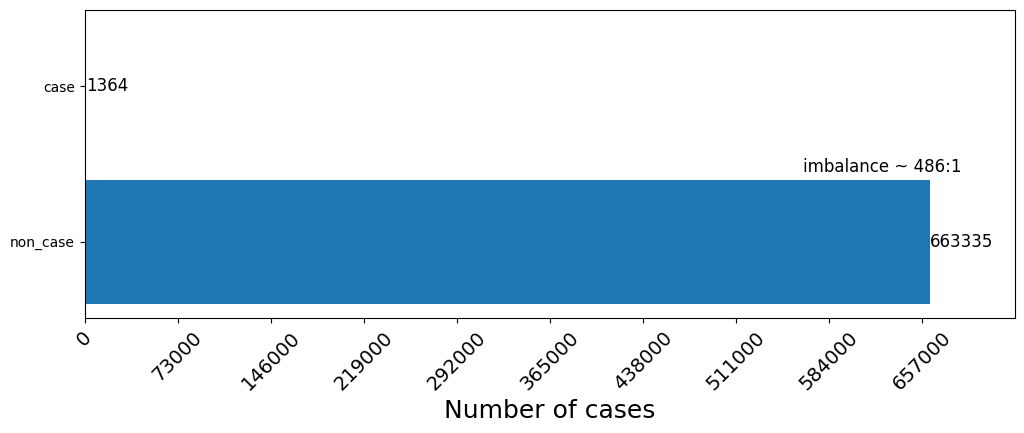

In [11]:
plot_imbalance(data_train, target_column='cases')

In [12]:
# plot_imbalance(data_test, target_column='cases')

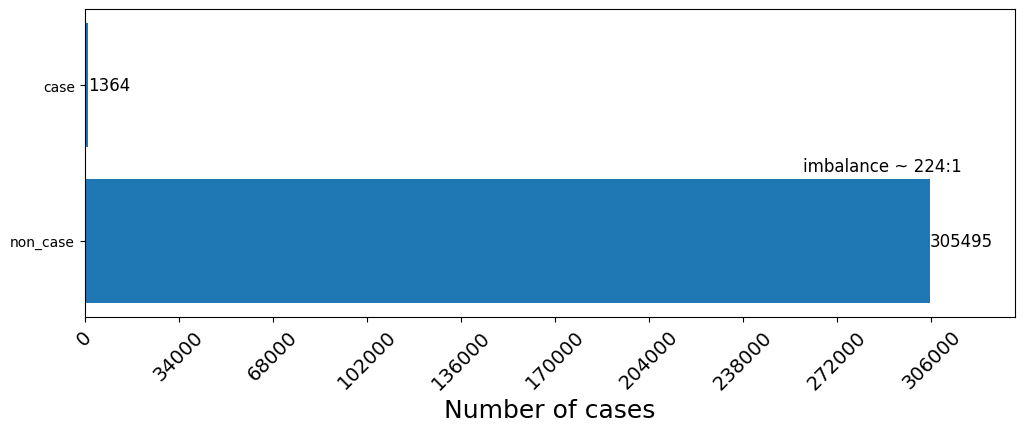

In [13]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [14]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

In [15]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

In [16]:
# data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# # dataset = dataset.query('month >= 5')
# data_train.reset_index(drop=True, inplace=True)

# plot_imbalance(data_train, target_column='cases')

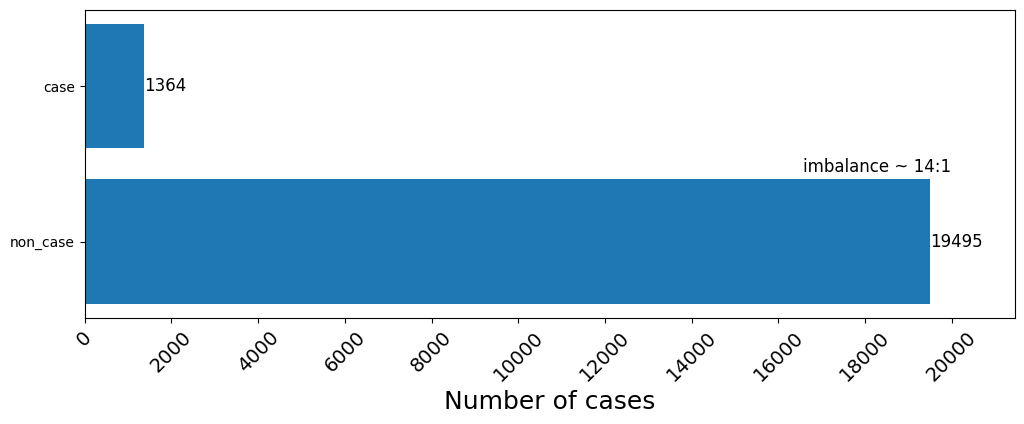

In [17]:
rows_to_remove = data_train.query('cases == 0').sample(n=286000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [18]:
data_train.shape

(20720, 94)

In [19]:
data_train.cases.sum()

1364

In [20]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1651,262,1913,6.30%
1,2011,1605,100,1705,16.05%
2,2012,1615,157,1772,10.29%
3,2013,1658,85,1743,19.51%
4,2014,1556,15,1571,103.73%
5,2015,1647,0,1647,inf%
6,2016,1659,0,1659,inf%
7,2017,1588,42,1630,37.81%
8,2018,1570,296,1866,5.30%
9,2019,1651,218,1869,7.57%


In [21]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [22]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 14.29
Weight: 14.29


In [23]:
data_test_may = data_test.query(f'month == 5').reset_index(drop=True)
data_test_jun = data_test.query(f'month == 6').reset_index(drop=True)
data_test_jul = data_test.query(f'month == 7').reset_index(drop=True)
data_test_aug = data_test.query(f'month == 8').reset_index(drop=True)
# data_test_sep = data_test.query(f'month == 9').reset_index(drop=True)
# data_test_oct = data_test.query(f'month == 10').reset_index(drop=True)

In [24]:
data_test

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,month_sin,month_cos
0,0,EL52,EL524,εδεσσας,2025,5,21.76334,40.79806,0.441360,-0.015914,-0.383688,0.015914,0.401796,-0.020465,-0.347536,0.020465,0.033484,0.032923,0.023345,0.032923,17.380435,6.032581,4.222143,15.582857,17.380435,8.303600,2.039032,-4.067600,4.233226,8.303600,12.940000,4.035806,0.077271,9.908041,12.842017,2.25,24.39,2.597000,24.119999,33.849999,77.909998,393.609992,14.000000,20.000000,44.444444,905.287498,39.0,-6.0,45.0,21.333333,21.500000,25.833333,3.666667,568.0,129.0,0.0,81.828630,246.0,70.0,129.0,99.0,31,30,30,10,10,1,6,6,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
1,1,EL52,EL524,εδεσσας,2025,5,21.76334,40.81603,0.397648,-0.076612,-0.384398,0.076612,0.373574,-0.098830,-0.368851,0.098830,0.024245,0.027474,0.011418,0.027474,18.797273,7.579032,4.416087,16.734286,18.797273,6.794348,2.329355,-3.960769,2.994667,6.794348,12.821364,4.954194,0.227659,9.864476,12.795810,-0.29,25.41,3.558000,36.399999,55.219999,106.739998,516.799987,13.250000,19.833333,44.074074,888.691582,37.0,-8.0,45.0,20.166667,20.500000,25.166667,3.333333,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,113.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
2,2,EL52,EL524,εδεσσας,2025,5,21.76334,40.83400,0.330997,-0.000262,-0.340467,0.000262,0.368599,-0.019522,-0.366404,0.019522,0.053833,0.038112,0.025462,0.038112,16.591818,7.156452,3.016087,17.131429,16.591818,4.890000,1.797742,-5.726522,1.494286,4.890000,10.775455,4.477097,-1.355217,9.312857,10.740909,-1.63,24.53,3.558000,36.399999,55.219999,106.739998,516.799987,12.833333,19.000000,43.181818,814.452782,36.0,-8.0,44.0,18.500000,19.666667,23.333333,3.000000,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,160.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
3,3,EL52,EL524,εδεσσας,2025,5,21.76334,40.85196,0.273317,-0.100367,-0.313515,0.100367,0.241994,0.005183,-0.231054,-0.005183,0.032152,0.038285,0.041299,0.038285,15.410909,4.993871,1.057857,14.072143,15.410909,5.691176,2.598387,-7.730000,1.964286,5.691176,10.621176,3.796129,-3.336071,8.018214,10.551043,3.47,22.31,3.558000,36.399999,55.219999,106.739998,516.799987,12.208333,17.416667,43.541667,788.686576,34.0,-6.0,40.0,17.500000,19.000000,22.500000,2.833333,632.0,150.0,0.0,85.453658,269.0,74.0,150.0,113.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,8195.0,38069.0,13922.0,60186.0,7828.0,37282.0,17281.0,62391.0,NaN,NaN,NaN,2,3,2,0.500000,-0.866025
4,4,EL52,EL524,εδεσσας,2025,5,21.78676,40.79806,-0.164273,0.389535,0.403936,-0.389535,0.005376,0.267220,0.193437,-0.267220,0.237368,0.184202,0.304666,0.184202,15.750000,6.545484,5.555833,12.886429,

### Results 2024 ###

In [25]:
X_test = data_test_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_may = pd.concat([data_test_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jun = pd.concat([data_test_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_jul = pd.concat([data_test_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_aug = pd.concat([data_test_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
# X_test = data_test_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_sep = pd.concat([data_test_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [30]:
# X_test = data_test_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])

# X_test_scaled = scaler.transform(X_test)
# X_test_imputed = imputer.transform(X_test_scaled)
    
# y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

# results_oct = pd.concat([data_test_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
results_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1936,1936,EL52,EL522,αμπελοκηπων μενεμενης,2025,5,22.88762,40.65433,0.080850
1123,1123,EL52,EL524,πελλας,2025,5,22.44259,40.76213,0.024130
1183,1183,EL52,EL524,πελλας,2025,5,22.46601,40.76213,0.023634
946,946,EL52,EL524,πελλας,2025,5,22.37232,40.78010,0.019232
3473,3473,EL52,EL526,σερρων,2025,5,23.49661,41.08553,0.016738


In [32]:
results_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3604,3604,EL52,EL526,σερρων,2025,6,23.54345,41.08553,0.664762
882,882,EL52,EL521,αλεξανδρειας,2025,6,22.34890,40.61840,0.567999
1820,1820,EL52,EL522,ωραιοκαστρου,2025,6,22.81735,40.69026,0.551864
1122,1122,EL52,EL524,πελλας,2025,6,22.44259,40.74416,0.539173
1003,1003,EL52,EL524,πελλας,2025,6,22.39575,40.72620,0.511147


In [33]:
results_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3604,3604,EL52,EL526,σερρων,2025,7,23.54345,41.08553,0.949224
3335,3335,EL52,EL526,βισαλτιας,2025,7,23.44976,40.94180,0.944830
2775,2775,EL52,EL527,νεας προποντιδας,2025,7,23.26238,40.27703,0.920181
3334,3334,EL52,EL526,βισαλτιας,2025,7,23.44976,40.92383,0.905582
1980,1980,EL52,EL522,κορδελιου ευοσμου,2025,7,22.91104,40.67230,0.904191


In [34]:
results_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3335,3335,EL52,EL526,βισαλτιας,2025,8,23.44976,40.94180,0.954186
3334,3334,EL52,EL526,βισαλτιας,2025,8,23.44976,40.92383,0.948727
3410,3410,EL52,EL526,σερρων,2025,8,23.47318,41.10350,0.939683
3148,3148,EL52,EL526,σιντικης,2025,8,23.37949,41.19333,0.939372
3671,3671,EL52,EL526,σερρων,2025,8,23.56687,41.10350,0.938680


In [35]:
# results_sep.sort_values(by='score', ascending=False).head(5)

In [36]:
# results_oct.sort_values(by='score', ascending=False).head(5)

In [37]:
folder_path = "E:/Drive/NOA/MBD-Prediction/Shapefiles/Greece Shapefiles"
region_grid = gpd.read_file(f'{base_folder}/{NUTS2}/{NUTS0}_{NUTS2}_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')
greece_lakes = gpd.read_file(f"{folder_path}/limnes/lakes.shp",  encoding='utf8')
wnv_groud_truth = pd.read_csv(f"../../../data/{NUTS0}_WNV_cases_GRID_2010-2021_processed.csv", encoding='utf8')
grid_index = gpd.read_file(f"../../../data/grid_index/grid_index.shp", encoding = 'utf-8')

In [38]:
region_grid = region_grid.to_crs(epsg=4326)
region_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
region_grid = region_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {region_grid.crs}')

greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == NUTS2_ID]
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1['buffered_geometry'] = greece_lau1['geometry'].buffer(-0.005)  # Adjust the buffer distance as needed
greece_lau1.set_geometry('buffered_geometry', inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop_duplicates(inplace=True)
greece_lau1.set_geometry('geometry', inplace=True)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME', 'buffered_geometry'], inplace=True)
greece_lau1.reset_index(drop = True, inplace = True)
print(f'greece_lau1 CRS: {greece_lau1.crs}')

greece_lakes = greece_lakes.to_crs(epsg=4326)
greece_lakes.drop(columns=['objectid','EU_CD','MS_CD','NAME','ALTNAME2','ALTNAME3','BASIN_CD','CHARACTER_'], inplace=True)
greece_lakes = greece_lakes.set_axis(['name', 'area', 'length', 'geometry'], axis=1)
greece_lakes_outer = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='overlaps')
greece_lakes_inner = gpd.sjoin(greece_lakes, greece_nuts2_gdf, op='within')
greece_lakes = pd.concat([greece_lakes_outer, greece_lakes_inner], axis=0)
greece_lakes = gpd.overlay(greece_nuts2_gdf, greece_lakes, how='intersection')
greece_lakes.drop(columns=['NUTS_ID_1','NUTS_NAME_1','index_right','NUTS_ID_2','NUTS_NAME_2'], inplace=True)
greece_lakes['u_key'] = greece_lakes.index

greece_lakes.reset_index(drop=True, inplace=True)
print(f'greece_lakes CRS: {greece_lakes.crs}')

grouped_by_cell = wnv_groud_truth.drop(columns=['onset of symptoms', 'day', 'nuts3','lau1','lau2']).groupby(['cell_code','year','month', 'nuts2'], as_index = False)
grouped_by_cell_sum = grouped_by_cell.sum()
grouped_by_cell_sum = grouped_by_cell_sum.set_axis(['cell_number', 'year','month', 'nuts2', 'cases'], axis=1)
grouped_by_cell_sum.reset_index(drop = True, inplace=True)

grid_index = grid_index.to_crs(epsg=4326)
grid_index.drop(columns=['PageNumber'], inplace=True)
grid_index = grid_index.set_axis(['cell_number', 'geometry'], axis=1)
grid_index['centroid'] = grid_index['geometry'].centroid
print(f'grid_index CRS: {grid_index.crs}')

grid_index = grid_index.merge(grouped_by_cell_sum, on=['cell_number'])

greece_index CRS: EPSG:4326
greece_nuts2 CRS: EPSG:4326
greece_lau1 CRS: EPSG:4326
greece_lakes CRS: EPSG:4326
grid_index CRS: EPSG:4326


In [39]:
region_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [40]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [41]:
greece_lau1.head()

,NAME,geometry
0,Δέλτα,"MULTIPOLYGON (((22.74653 40.51249, 22.74682 40..."
1,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
2,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
3,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
4,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."


In [42]:
greece_lakes.head()

,name,area,length,geometry,u_key
0,DOIRANI LAKE,38845664.0,23830.293,"POLYGON ((22.74871 41.17307, 22.75127 41.19256...",0
1,VEGORITIDA LAKE,53967632.0,44307.140,"POLYGON ((21.78009 40.74340, 21.79369 40.77087...",1
2,SFIKIAS RESERVOIR,3668518.8,24065.023,"MULTIPOLYGON (((22.15441 40.35638, 22.15217 40...",2
3,KERKINI LAKE,46088780.0,70604.010,"POLYGON ((23.08406 41.20032, 23.08512 41.20179...",3
4,PIKROLIMNI RESERVOIR,4270964.0,9538.072,"POLYGON ((22.79801 40.83966, 22.79871 40.84039...",4


In [43]:
results_may = pd.merge(results_may, region_grid, on='cell_number', how='left')
results_may = gpd.GeoDataFrame(results_may, geometry='geometry')
results_may['x'] = results_may['x'].round(4)
results_may['y'] = results_may['y'].round(4)
results_may.rename(columns={'score': 'risk_score'}, inplace=True)
results_may['risk_score'] = results_may['risk_score'].round(6)

results_jun = pd.merge(results_jun, region_grid, on='cell_number', how='left')
results_jun = gpd.GeoDataFrame(results_jun, geometry='geometry')
results_jun['x'] = results_jun['x'].round(4)
results_jun['y'] = results_jun['y'].round(4)
results_jun.rename(columns={'score': 'risk_score'}, inplace=True)
results_jun['risk_score'] = results_jun['risk_score'].round(6)

results_jul = pd.merge(results_jul, region_grid, on='cell_number', how='left')
results_jul = gpd.GeoDataFrame(results_jul, geometry='geometry')
results_jul['x'] = results_jul['x'].round(4)
results_jul['y'] = results_jul['y'].round(4)
results_jul.rename(columns={'score': 'risk_score'}, inplace=True)
results_jul['risk_score'] = results_jul['risk_score'].round(6)

results_aug = pd.merge(results_aug, region_grid, on='cell_number', how='left')
results_aug = gpd.GeoDataFrame(results_aug, geometry='geometry')
results_aug['x'] = results_aug['x'].round(4)
results_aug['y'] = results_aug['y'].round(4)
results_aug.rename(columns={'score': 'risk_score'}, inplace=True)
results_aug['risk_score'] = results_aug['risk_score'].round(6)

# results_sep = pd.merge(results_sep, region_grid, on='cell_number', how='left')
# results_sep = gpd.GeoDataFrame(results_sep, geometry='geometry')
# results_sep['x'] = results_sep['x'].round(4)
# results_sep['y'] = results_sep['y'].round(4)
# results_sep.rename(columns={'score': 'risk_score'}, inplace=True)
# results_sep['risk_score'] = results_sep['risk_score'].round(6)

# results_oct = pd.merge(results_oct, region_grid, on='cell_number', how='left')
# results_oct = gpd.GeoDataFrame(results_oct, geometry='geometry')
# results_oct['x'] = results_oct['x'].round(4)
# results_oct['y'] = results_oct['y'].round(4)
# results_oct.rename(columns={'score': 'risk_score'}, inplace=True)
# results_oct['risk_score'] = results_oct['risk_score'].round(6)

In [44]:
# results_may.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jun.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_June_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_jul.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_July_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

results_aug.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_August_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

# results_sep.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_September_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)
# results_oct.to_file(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_October_{TEST_YEAR}.shp', encoding = 'utf-8', index = False)

In [45]:
float_column = 'risk_score'
geometry_column = 'geometry'
cmap = plt.cm.coolwarm
figure_size = (15,9)
lake_face_color = '#c4dff4'
lake_edge_color = '#0978ab'
lake_line_w = 0.4
nuts_face_color = 'none'
boundry_color = 'black'
nuts_line_w = 1.5
lau_line_w = 0.8
lau_opacity = 0.35
title_size = 22
point_color = '#FF0000'
month_dict = {5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

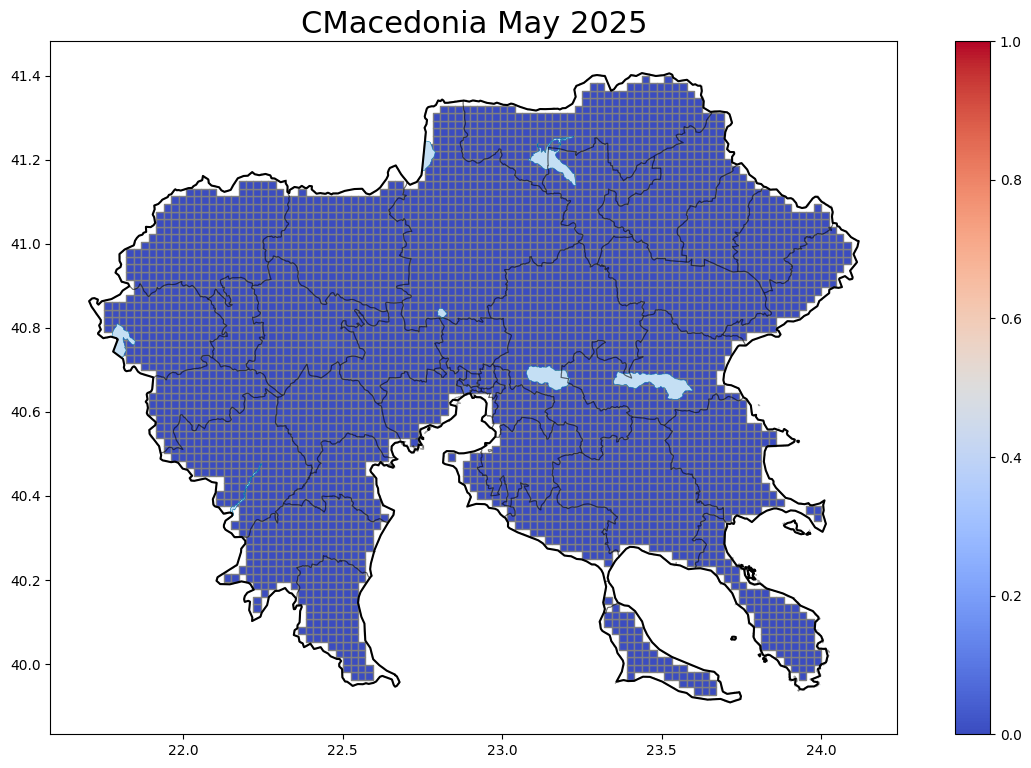

In [46]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 5)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_may.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

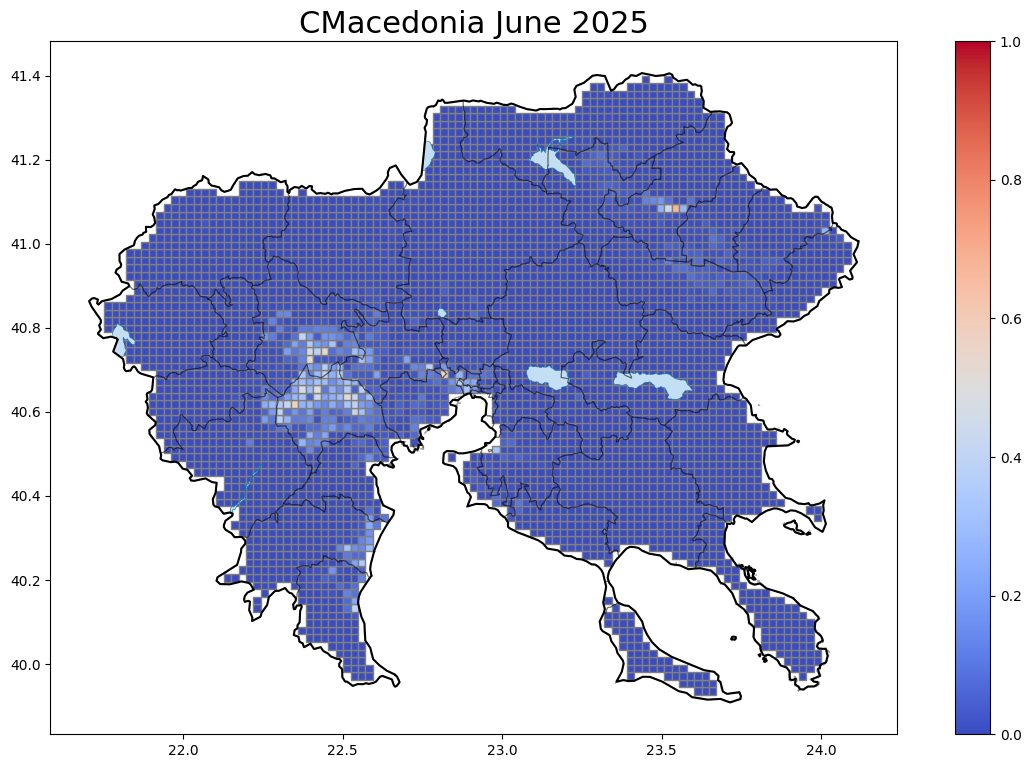

In [47]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 6)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jun.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

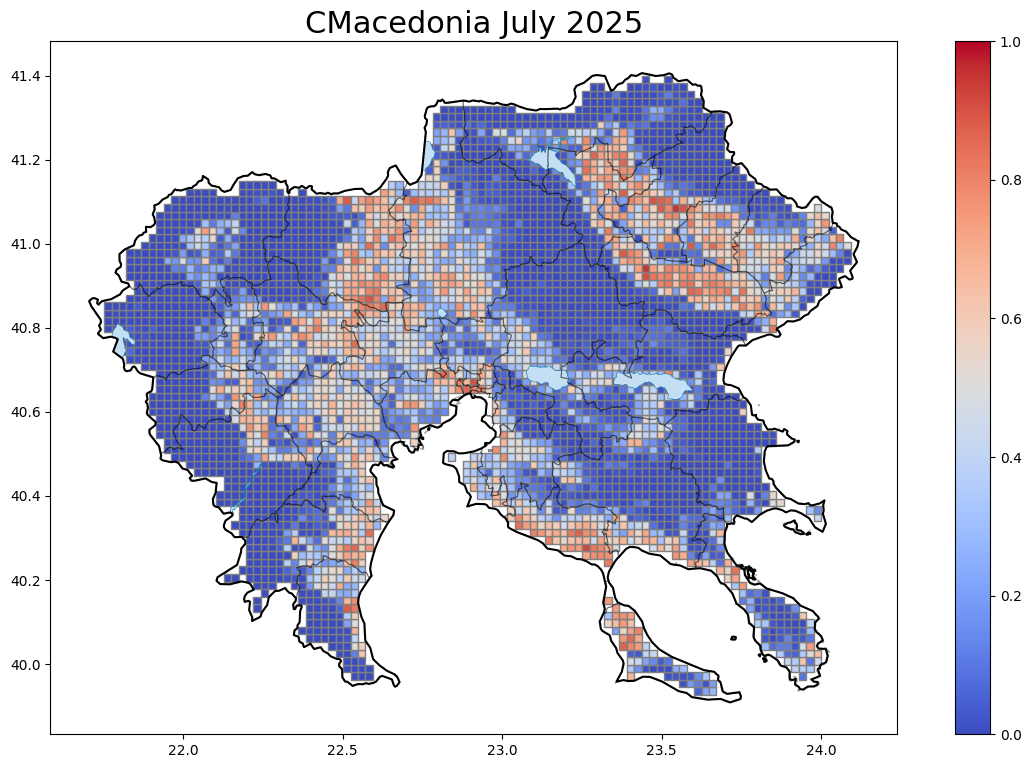

In [48]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 7)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_jul.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

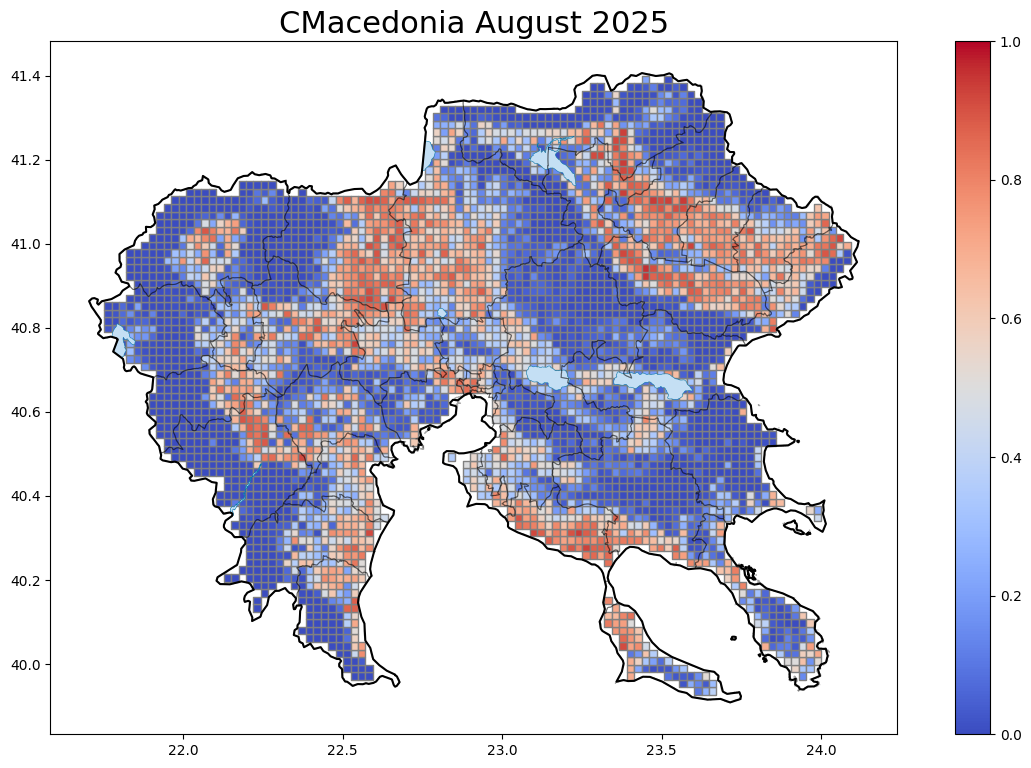

In [49]:
fig, ax = plt.subplots(figsize=figure_size)
wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
wnv_cases_grid.set_geometry('centroid', inplace = True)

# Plot the geometry column with the colors based on the float column
results_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
try:
    wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
except ValueError:
    pass

plt.title(f'{NUTS2} {month_dict.get(results_aug.month.iloc[0])} {TEST_YEAR}', size = title_size)
plt.show()

In [50]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 9)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_sep.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [51]:
# fig, ax = plt.subplots(figsize=figure_size)
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 10)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# # Plot the geometry column with the colors based on the float column
# results_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey', legend=True, vmin = 0, vmax = 1)
# greece_lakes.plot(ax=ax, color=lake_face_color, edgecolor=lake_edge_color, linewidth = lake_line_w)
# greece_nuts2_gdf.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = nuts_line_w)
# greece_lau1.plot(ax=ax, color=nuts_face_color, edgecolor=boundry_color, linewidth = lau_line_w, alpha = lau_opacity)
# try:
#     wnv_cases_grid.plot(ax=ax, color = point_color, markersize = 10)
# except ValueError:
#     pass

# plt.title(f'{NUTS2} {month_dict.get(results_oct.month.iloc[0])} {TEST_YEAR}', size = title_size)
# plt.show()

In [52]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_may, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


#====================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [53]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jun, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


#====================================================================================================================================================
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [54]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_jul, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()


# 
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [55]:
# wnv_cases_grid = grid_index[(grid_index['nuts2'] == NUTS2_EL) & (grid_index['year'] == int(TEST_YEAR)) & (grid_index['month'] == 8)]
# wnv_cases_grid.set_geometry('centroid', inplace = True)

# fig = interactive_colored_mapbox(results_aug, greece_lakes, greece_nuts2_gdf, greece_lau1, wnv_cases_grid, 
#                                  index_col='cell_number', color_col='risk_score', hover_name='lau1', 
#                                  hover_data={'risk_score':True, 'x': True, 'y': True, 'nuts3_id': True, 'cell_number': False}, 
#                                  center={'lat': greece_nuts2_gdf.geometry.centroid.y.iloc[0], 
#                                          'lon': greece_nuts2_gdf.geometry.centroid.x.iloc[0]},
#                                  zoom=7.5, cmap=matplotlib_to_plotly(cmap), opacity=0.75, 
#                                  index_col_f2='u_key', hover_name_f2='name', color_f2='#aad3df', line_width_f4=0.8,
#                                  hover_data_f2={'u_key': False, 'area':True, 'length':True}, fig_height=800, size_f5=6.5)

# fig.show()

# 
# fig.write_html(f"E:/Drive/NOA/Presentations/Internal Presentations/2x2_GRID_{NUTS2_ID}_August_2018.html")
# fig_json = fig.to_json()

# # Write the JSON string to a JavaScript file
# with open("choropleth_map.js", "w") as js_file:
#     js_file.write("var fig = ")
#     js_file.write(fig_json)
#     js_file.write(";")

In [56]:
results_may

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL52,EL524,εδεσσας,2025,5,21.7633,40.7981,0.000072,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,EL524,εδεσσας,2025,5,21.7633,40.8160,0.000032,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,EL524,εδεσσας,2025,5,21.7633,40.8340,0.000009,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,EL524,εδεσσας,2025,5,21.7633,40.8520,0.000004,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,EL524,εδεσσας,2025,5,21.7868,40.7981,0.000904,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."
...,...,...,...,...,...,...,...,...,...,...
4411,4411,EL52,EL526,αμφιπολης,2025,5,24.0588,40.9957,0.000572,"POLYGON ((24.07046 40.98671, 24.04704 40.98671..."
4412,4412,EL52,EL526,αμφιπολης,2025,5,24.0588,41.0137,0.005302,"POLYGON ((24.07046 41.00468, 24.04704 41.00468..."
4413,4413,EL52,EL526,αμφιπολης,2025,5,24.0822,40.9598,0.000028,"POLYGON ((24.09388 40.95078, 24.07046 40.95078..."
4414,4414,EL52,EL526,αμφιπολης,2025,5,24.0822,40.9777,0.000025,"POLYGON ((24.09388 40.96875, 24.07046 40.96875..."


In [57]:
# results_may_to_send = results_may[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_may_to_send['cell_id'] = results_may_to_send['nuts3_id'] + '-' + results_may_to_send['cell_number'].astype(str).str.zfill(4)
# results_may_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_may_to_send['lau1'] = results_may_to_send['lau1'].str.upper()
# results_may_to_send = results_may_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_may_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_May_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_may_to_send

In [58]:
results_jun

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL52,EL524,εδεσσας,2025,6,21.7633,40.7981,0.000104,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,EL524,εδεσσας,2025,6,21.7633,40.8160,0.000037,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,EL524,εδεσσας,2025,6,21.7633,40.8340,0.000096,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,EL524,εδεσσας,2025,6,21.7633,40.8520,0.000114,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,EL524,εδεσσας,2025,6,21.7868,40.7981,0.000929,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."
...,...,...,...,...,...,...,...,...,...,...
4411,4411,EL52,EL526,αμφιπολης,2025,6,24.0588,40.9957,0.000519,"POLYGON ((24.07046 40.98671, 24.04704 40.98671..."
4412,4412,EL52,EL526,αμφιπολης,2025,6,24.0588,41.0137,0.032527,"POLYGON ((24.07046 41.00468, 24.04704 41.00468..."
4413,4413,EL52,EL526,αμφιπολης,2025,6,24.0822,40.9598,0.000002,"POLYGON ((24.09388 40.95078, 24.07046 40.95078..."
4414,4414,EL52,EL526,αμφιπολης,2025,6,24.0822,40.9777,0.000022,"POLYGON ((24.09388 40.96875, 24.07046 40.96875..."


In [59]:
# results_jun_to_send = results_jun[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_jun_to_send['cell_id'] = results_jun_to_send['nuts3_id'] + '-' + results_jun_to_send['cell_number'].astype(str).str.zfill(4)
# results_jun_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_jun_to_send['lau1'] = results_jun_to_send['lau1'].str.upper()
# results_jun_to_send = results_jun_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_jun_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jun_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_jun_to_send

In [60]:
results_jul

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL52,EL524,εδεσσας,2025,7,21.7633,40.7981,0.001177,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,EL524,εδεσσας,2025,7,21.7633,40.8160,0.000589,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,EL524,εδεσσας,2025,7,21.7633,40.8340,0.000664,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,EL524,εδεσσας,2025,7,21.7633,40.8520,0.000081,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,EL524,εδεσσας,2025,7,21.7868,40.7981,0.011538,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."
...,...,...,...,...,...,...,...,...,...,...
4411,4411,EL52,EL526,αμφιπολης,2025,7,24.0588,40.9957,0.294229,"POLYGON ((24.07046 40.98671, 24.04704 40.98671..."
4412,4412,EL52,EL526,αμφιπολης,2025,7,24.0588,41.0137,0.807647,"POLYGON ((24.07046 41.00468, 24.04704 41.00468..."
4413,4413,EL52,EL526,αμφιπολης,2025,7,24.0822,40.9598,0.000025,"POLYGON ((24.09388 40.95078, 24.07046 40.95078..."
4414,4414,EL52,EL526,αμφιπολης,2025,7,24.0822,40.9777,0.001550,"POLYGON ((24.09388 40.96875, 24.07046 40.96875..."


In [61]:
# results_jul_to_send = results_jul[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_jul_to_send['cell_id'] = results_jul_to_send['nuts3_id'] + '-' + results_jul_to_send['cell_number'].astype(str).str.zfill(4)
# results_jul_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_jul_to_send['lau1'] = results_jul_to_send['lau1'].str.upper()
# results_jul_to_send = results_jul_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_jul_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Jul_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_jul_to_send

In [62]:
results_aug

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,risk_score,geometry
0,0,EL52,EL524,εδεσσας,2025,8,21.7633,40.7981,0.019799,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,EL524,εδεσσας,2025,8,21.7633,40.8160,0.003620,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,EL524,εδεσσας,2025,8,21.7633,40.8340,0.010973,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,EL524,εδεσσας,2025,8,21.7633,40.8520,0.002780,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,EL524,εδεσσας,2025,8,21.7868,40.7981,0.084805,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."
...,...,...,...,...,...,...,...,...,...,...
4411,4411,EL52,EL526,αμφιπολης,2025,8,24.0588,40.9957,0.563835,"POLYGON ((24.07046 40.98671, 24.04704 40.98671..."
4412,4412,EL52,EL526,αμφιπολης,2025,8,24.0588,41.0137,0.919950,"POLYGON ((24.07046 41.00468, 24.04704 41.00468..."
4413,4413,EL52,EL526,αμφιπολης,2025,8,24.0822,40.9598,0.000074,"POLYGON ((24.09388 40.95078, 24.07046 40.95078..."
4414,4414,EL52,EL526,αμφιπολης,2025,8,24.0822,40.9777,0.011842,"POLYGON ((24.09388 40.96875, 24.07046 40.96875..."


In [63]:
results_aug_to_send = results_aug[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
results_aug_to_send['cell_id'] = results_aug_to_send['nuts3_id'] + '-' + results_aug_to_send['cell_number'].astype(str).str.zfill(4)
results_aug_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
results_aug_to_send['lau1'] = results_aug_to_send['lau1'].str.upper()
results_aug_to_send = results_aug_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
results_aug_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Aug_{TEST_YEAR}.csv', index=False, encoding='utf-8')
results_aug_to_send

,cell_id,lau1,month,year,x,y,risk_score
0,EL524-0000,ΕΔΕΣΣΑΣ,8,2025,21.7633,40.7981,0.019799
1,EL524-0001,ΕΔΕΣΣΑΣ,8,2025,21.7633,40.8160,0.003620
2,EL524-0002,ΕΔΕΣΣΑΣ,8,2025,21.7633,40.8340,0.010973
3,EL524-0003,ΕΔΕΣΣΑΣ,8,2025,21.7633,40.8520,0.002780
4,EL524-0004,ΕΔΕΣΣΑΣ,8,2025,21.7868,40.7981,0.084805
...,...,...,...,...,...,...,...
4411,EL526-4411,ΑΜΦΙΠΟΛΗΣ,8,2025,24.0588,40.9957,0.563835
4412,EL526-4412,ΑΜΦΙΠΟΛΗΣ,8,2025,24.0588,41.0137,0.919950
4413,EL526-4413,ΑΜΦΙΠΟΛΗΣ,8,2025,24.0822,40.9598,0.000074
4414,EL526-4414,ΑΜΦΙΠΟΛΗΣ,8,2025,24.0822,40.9777,0.011842


In [64]:
# results_sep

In [65]:
# results_sep_to_send = results_sep[['cell_number', 'nuts3_id', 'lau1', 'year', 'month', 'x', 'y', 'risk_score']].copy()
# results_sep_to_send['cell_id'] = results_sep_to_send['nuts3_id'] + '-' + results_sep_to_send['cell_number'].astype(str).str.zfill(4)
# results_sep_to_send.drop(columns=['cell_number', 'nuts3_id'], inplace=True)
# results_sep_to_send['lau1'] = results_sep_to_send['lau1'].str.upper()
# results_sep_to_send = results_sep_to_send[['cell_id', 'lau1', 'month', 'year', 'x', 'y', 'risk_score']]
# results_sep_to_send.to_csv(f'../../../data/{NUTS2}/predictions/{NUTS0}_{NUTS2}_Predictions_Sep_{TEST_YEAR}.csv', index=False, encoding='utf-8')
# results_sep_to_send